<a href="https://colab.research.google.com/github/Supieiei/Project1_Group7/blob/kunthida-jj/Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**นางสาวกุลธิดา สมาขันธ์ 673020245-1**

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [123]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# ใช้ฟอนต์ที่มีใน Colab
mpl.rcParams["font.family"] = "Noto Sans Thai"
mpl.rcParams["font.sans-serif"] = ["Noto Sans Thai"]
mpl.rcParams["axes.unicode_minus"] = False

In [73]:
import json
import pandas as pd

In [74]:
import os

os.listdir()

['.config',
 'bluesky.jsonl',
 'posts_20241127_075347 (1).jsonl',
 'posts_20241127_075630 (1).jsonl',
 'sample_data']

In [75]:
file_path = "bluesky_posts.jsonl"

In [76]:
!wget -O bluesky.jsonl "https://huggingface.co/datasets/alpindale/two-million-bluesky-posts/resolve/main/posts_20241127_075630.jsonl"

--2026-10-06 12:53:51--  https://huggingface.co/datasets/alpindale/two-million-bluesky-posts/resolve/main/posts_20241127_075630.jsonl
Resolving huggingface.co (huggingface.co)... 3.171.171.128, 3.171.171.104, 3.171.171.6, ...
Connecting to huggingface.co (huggingface.co)|3.171.171.128|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6747510080aebd7436aa497d/f8494388ba1f815de8b2b4c80a5af8117423e15c071ef72045b8bb8969e8954d?xip=pORDouiKxgk&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27posts_20241127_075630.jsonl%3B+filename%3D%22posts_20241127_075630.jsonl%22%3B&user_id=public&Expires=1791294832&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjc0NzUxMDA4MGFlYmQ3NDM2YWE0OTdkL2Y4NDk0Mzg4YmExZjgxNWRlOGIyYjRjODBhNWFmODExNzQyM2UxNWMwNzFlZjcyMDQ1YjhiYjg5NjllODk1NGRcXD94aXA9cE9SRG91aUt4Z2smWC1YZXQtQ2FzLVVpZD1wdWJsaWMmcmVzcG9uc2UtY29udGVudC1kaXN

In [77]:
import os

os.path.getsize("bluesky.jsonl") / (1024**2)

38.075504302978516

In [78]:
import json

with open("bluesky.jsonl", "r", encoding="utf-8") as f:
    first_post = json.loads(f.readline())

print(first_post)

{'text': '기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 쳐내주는 둠네사', 'created_at': '2024-11-27T07:56:28.535Z', 'author': 'did:plc:z3dbv7bbotsaxzdmmlwoypha', 'uri': 'at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky.feed.post/3lbw3attebk2o', 'has_images': False, 'reply_to': None}


In [79]:
import pandas as pd

df = pd.read_json("bluesky.jsonl", lines=True)

print("จำนวนโพสต์:", len(df))
print("จำนวนคอลัมน์:", len(df.columns))

df.head()

จำนวนโพสต์: 100000
จำนวนคอลัมน์: 6


,text,created_at,author,uri,has_images,reply_to
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z,did:plc:z3dbv7bbotsaxzdmmlwoypha,at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky...,False,None
1,Lovely stuff.,2024-11-27T07:56:28.717Z,did:plc:4dn3nlaku6z3ltxzkxglyqdq,at://did:plc:4dn3nlaku6z3ltxzkxglyqdq/app.bsky...,False,at://did:plc:y7vhfdg5iq7qbotunr767enp/app.bsky...
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z,did:plc:fn4xjeryjchlrtjwippuumxm,at://did:plc:fn4xjeryjchlrtjwippuumxm/app.bsky...,True,None
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。,2024-11-27T07:56:28.499Z,did:plc:aaf7jrpncnzlbiqfzkgugowq,at://did:plc:aaf7jrpncnzlbiqfzkgugowq/app.bsky...,False,None
4,WoAH,2024-11-27T07:56:29.868Z,did:plc:l6fvehl7vj44d44aydnds7qr,at://did:plc:l6fvehl7vj44d44aydnds7qr/app.bsky...,False,at://did:plc:54ordrb4cjngwlivuadayono/app.bsky...


In [113]:
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [114]:
plt.rcParams["font.family"] = "Garuda"

In [115]:
!apt-get -qq install fonts-noto-core

In [116]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Noto Sans Thai"
plt.rcParams["axes.unicode_minus"] = False

###**ข้อที่ 1 คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

In [80]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

df[["created_at"]].head()

/tmp/ipykernel_1020/4058831755.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")


,created_at
0,2024-11-27 07:56:28.535000+00:00
1,2024-11-27 07:56:28.717000+00:00
2,2024-11-27 07:56:21.343000+00:00
3,2024-11-27 07:56:28.499000+00:00
4,2024-11-27 07:56:29.868000+00:00


In [81]:
print("วันที่อ่านไม่ได้:", df["created_at"].isna().sum())

วันที่อ่านไม่ได้: 6745


In [82]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

df["created_at"].head()

,created_at
0,2024-11-27 07:56:28.535000+00:00
1,2024-11-27 07:56:28.717000+00:00
2,2024-11-27 07:56:21.343000+00:00
3,2024-11-27 07:56:28.499000+00:00
4,2024-11-27 07:56:29.868000+00:00


In [83]:
daily_posts = (
    df.groupby(df["created_at"].dt.date)
      .size()
      .reset_index(name="post_count")
)

daily_posts.head()

,created_at,post_count
0,2012-10-25,1
1,2012-10-27,137
2,2012-10-28,194
3,2012-10-29,214
4,2013-03-11,1


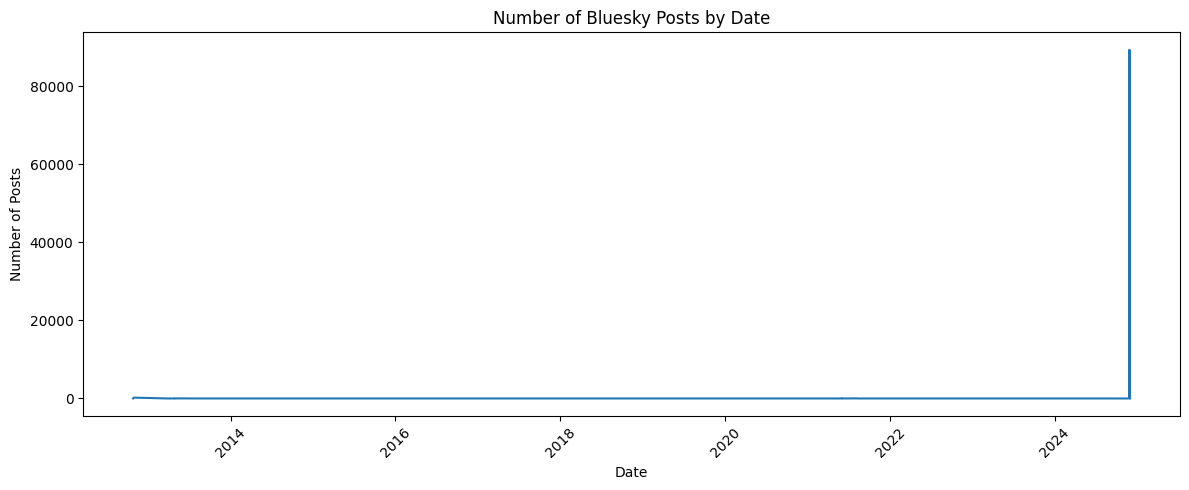

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    daily_posts["created_at"],
    daily_posts["post_count"]
)

plt.title("Number of Bluesky Posts by Date")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [85]:
top_day = daily_posts.loc[
    daily_posts["post_count"].idxmax()
]

print("วันที่มีโพสต์มากที่สุด:", top_day["created_at"])
print("จำนวนโพสต์:", top_day["post_count"])

วันที่มีโพสต์มากที่สุด: 2024-11-27
จำนวนโพสต์: 89331


In [86]:
df["hour"] = df["created_at"].dt.hour

hourly_posts = (
    df.groupby("hour")
      .size()
      .reset_index(name="post_count")
)

hourly_posts

,hour,post_count
0,0.0,81
1,1.0,117
2,2.0,108
3,3.0,73
4,4.0,90
5,5.0,147
6,6.0,144
7,7.0,10425
8,8.0,79035
9,9.0,177


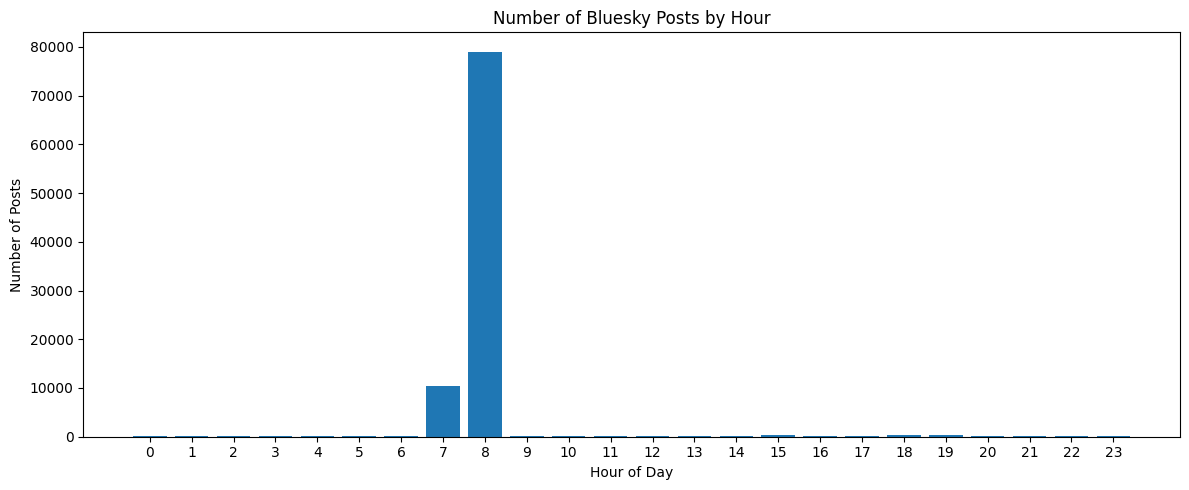

In [125]:
plt.figure(figsize=(12, 5))

plt.bar(
    hourly_posts.index,
    hourly_posts.values
)

plt.title("Number of Bluesky Posts by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Posts")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [88]:
print("จำนวนโพสต์ทั้งหมด:", len(df))

print("ช่วงเวลาเริ่มต้น:", df["created_at"].min())
print("ช่วงเวลาสิ้นสุด:", df["created_at"].max())

df["hour"] = df["created_at"].dt.hour

hourly_posts = df.groupby("hour").size()

peak_hour = int(hourly_posts.idxmax())
peak_count = int(hourly_posts.max())

print(f"ชั่วโมงที่โพสต์มากที่สุด: {peak_hour:02d}:00–{peak_hour:02d}:59 UTC")
print(f"จำนวนโพสต์: {peak_count:,}")

จำนวนโพสต์ทั้งหมด: 100000
ช่วงเวลาเริ่มต้น: 2012-10-25 08:22:45+00:00
ช่วงเวลาสิ้นสุด: 2024-11-30 10:50:04.343000+00:00
ชั่วโมงที่โพสต์มากที่สุด: 08:00–08:59 UTC
จำนวนโพสต์: 79,035


**จำนวนโพสต์ :** 100,000 โพสต์

**ช่วงเวลาที่ข้อมูลครอบคลุม :**
เริ่ม 25 ตุลาคม 2012 08:22:45 UTC
สิ้นสุด 30 พฤศจิกายน 2024 10:50:04 UTC

**ชั่วโมงที่โพสต์มากที่สุด :** 08:00–08:59 UTC
จำนวนโพสต์: 79,035

###**ข้อที่ 2 ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

In [89]:
print(df.columns.tolist())

['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to', 'hour']


In [90]:
!pip install langdetect

In [91]:
from langdetect import detect

text = df["text"].dropna().iloc[0]

print("ข้อความ:")
print(text)

print("\nภาษาที่ตรวจพบ:")
print(detect(text))

ข้อความ:
기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 쳐내주는 둠네사

ภาษาที่ตรวจพบ:
ko


In [71]:
from langdetect import detect, DetectorFactory

# ทำให้ผลลัพธ์คงที่
DetectorFactory.seed = 0

def detect_language(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return "unknown"
        return detect(str(text))
    except:
        return "unknown"

df["language"] = df["text"].apply(detect_language)

In [72]:
language_percent = (
    df["language"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(language_percent)

language
en         48.07
ja         13.15
unknown     5.72
es          4.93
de          4.34
ko          3.84
fr          3.23
nl          1.50
pt          1.41
it          1.21
tr          1.04
pl          0.97
ru          0.83
af          0.69
ca          0.66
fi          0.66
so          0.60
id          0.56
no          0.55
da          0.52
sv          0.49
cy          0.43
tl          0.42
th          0.41
ro          0.31
el          0.30
zh-cn       0.28
ur          0.27
et          0.26
cs          0.24
hr          0.24
sk          0.22
sw          0.21
vi          0.20
he          0.19
uk          0.17
sl          0.15
hu          0.11
bg          0.10
ar          0.08
fa          0.08
lv          0.08
lt          0.07
zh-tw       0.07
mk          0.07
sq          0.05
hi          0.01
ml          0.00
mr          0.00
bn          0.00
pa          0.00
ta          0.00
ne          0.00
te          0.00
Name: proportion, dtype: float64


In [93]:
print(language_counts)

language
en         48074
ja         13152
unknown     5724
es          4926
de          4341
ko          3835
fr          3228
nl          1500
pt          1409
it          1206
tr          1044
pl           972
ru           826
af           687
ca           662
fi           659
so           605
id           558
no           550
da           521
sv           493
cy           433
tl           417
th           412
ro           314
el           299
zh-cn        277
ur           274
et           263
cs           237
hr           237
sk           221
sw           207
vi           196
he           190
uk           169
sl           146
hu           109
bg            98
ar            80
fa            77
lv            77
lt            73
zh-tw         72
mk            71
sq            54
hi            13
ml             4
mr             2
bn             2
pa             1
ta             1
ne             1
te             1
Name: count, dtype: int64


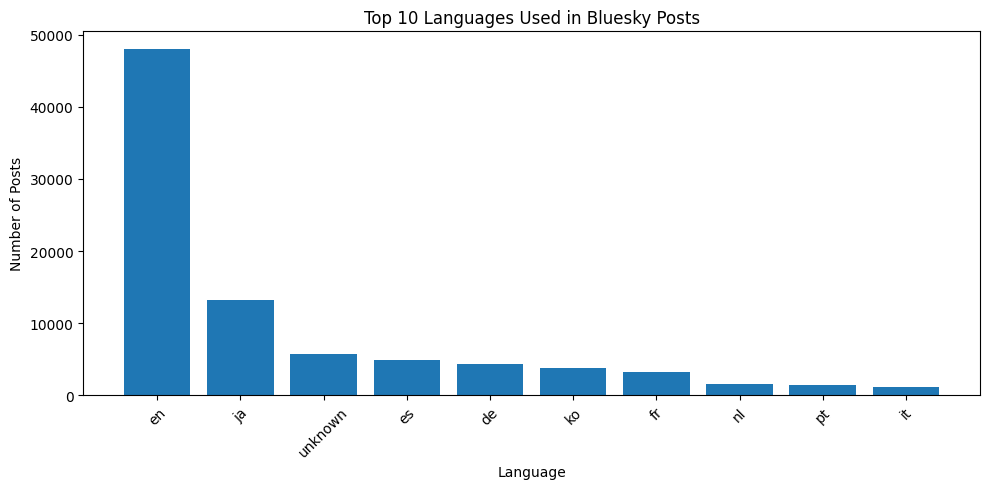

In [117]:
import matplotlib.pyplot as plt
import pandas as pd
from langdetect import detect, DetectorFactory

# ทำให้ผลลัพธ์คงที่
DetectorFactory.seed = 0

def detect_language(text):
    try:
        if pd.isna(text) or str(text).strip() == "":
            return "unknown"
        return detect(str(text))
    except:
        return "unknown"

# Ensure 'language' column exists before proceeding
if "language" not in df.columns:
    df["language"] = df["text"].apply(detect_language)

top_languages = df["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_languages.index,
    top_languages.values
)

plt.title("Top 10 Languages Used in Bluesky Posts")
plt.xlabel("Language")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [97]:
language_names = {
    "en": "English",
    "es": "Spanish",
    "pt": "Portuguese",
    "de": "German",
    "fr": "French",
    "ja": "Japanese",
    "ko": "Korean",
    "zh-cn": "Chinese",
    "zh-tw": "Chinese",
    "it": "Italian",
    "nl": "Dutch",
    "ru": "Russian",
    "th": "Thai",
    "tr": "Turkish",
    "pl": "Polish",
    "unknown": "Unknown"
}

language_summary = df["language"].value_counts().head(10).reset_index()

language_summary.columns = ["language", "post_count"]

language_summary["language_name"] = (
    language_summary["language"]
    .map(language_names)
    .fillna(language_summary["language"])
)

language_summary["percent"] = (
    language_summary["post_count"] / len(df) * 100
).round(2)

language_summary

,language,post_count,language_name,percent
0,en,48074,English,48.07
1,ja,13152,Japanese,13.15
2,unknown,5724,Unknown,5.72
3,es,4926,Spanish,4.93
4,de,4341,German,4.34
5,ko,3835,Korean,3.84
6,fr,3228,French,3.23
7,nl,1500,Dutch,1.50
8,pt,1409,Portuguese,1.41
9,it,1206,Italian,1.21


In [99]:
top = language_summary.iloc[0]

print(
    f"ภาษาที่พบมากที่สุด: {top['language_name']} "
    f"จำนวน {top['post_count']:,} โพสต์ "
    f"คิดเป็น {top['percent']:.2f}% ของข้อมูล"
)

second = language_summary.iloc[1]

print(
    f"ภาษาที่พบมากเป็นอันดับ 2: {second['language_name']} "
    f"จำนวน {second['post_count']:,} โพสต์ "
    f"คิดเป็น {second['percent']:.2f}% ของข้อมูล"
)

ภาษาที่พบมากที่สุด: English จำนวน 48,074 โพสต์ คิดเป็น 48.07% ของข้อมูล
ภาษาที่พบมากเป็นอันดับ 2: Japanese จำนวน 13,152 โพสต์ คิดเป็น 13.15% ของข้อมูล


**ภาษาที่พบมากที่สุด:** ภาษาอังกฤษ (English) จำนวน 48,074 โพสต์  
**สัดส่วนภาษาอังกฤษ:** 57.74%  
**รองลงมา:** Japanese จำนวน 13,152 โพสต์ คิดเป็น 13.15%

###**ข้อ 3: คนพูดถึงอะไร?**

In [100]:
import re
from collections import Counter

# รวมข้อความทั้งหมด
all_text = df["text"].dropna().astype(str)

# ดึง hashtag
hashtags = []

for text in all_text:
    tags = re.findall(r"#\w+", text.lower())
    hashtags.extend(tags)

hashtag_counts = Counter(hashtags)

print("จำนวน hashtag ทั้งหมด:", len(hashtags))
print("\nHashtag ที่พบมากที่สุด 20 อันดับแรก:")

for tag, count in hashtag_counts.most_common(20):
    print(tag, ":", count)

จำนวน hashtag ทั้งหมด: 28167

Hashtag ที่พบมากที่สุด 20 อันดับแรก:
#art : 261
#nsfw : 175
#booksky : 142
#innovation : 137
#photography : 122
#nowplaying : 108
#books : 103
#bookchallenge : 87
#bluesky : 81
#ai : 77
#cybersécurité : 74
#oc : 69
#digitalart : 69
#gay : 68
#ssi : 68
#porn : 63
#nature : 59
#vtuber : 54
#periscope : 54
#illustration : 53


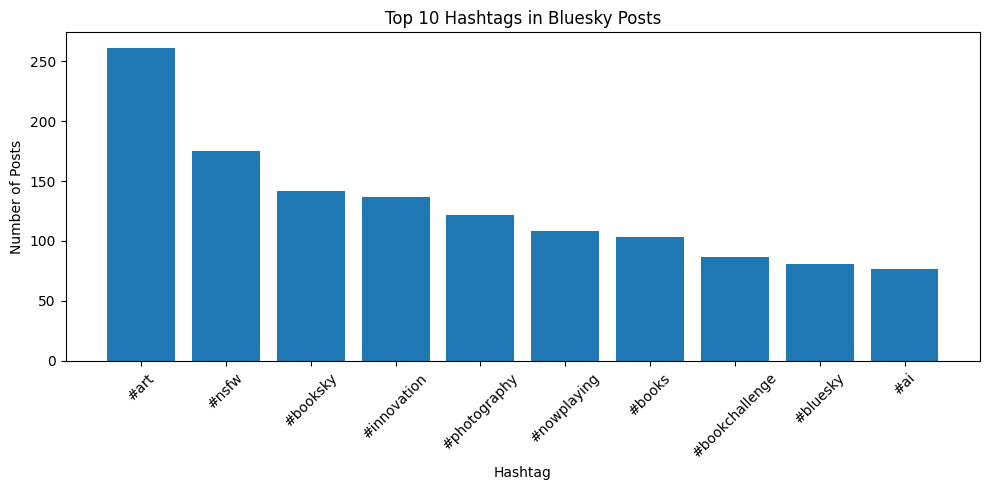

In [101]:
top_hashtags = hashtag_counts.most_common(10)

tags = [x[0] for x in top_hashtags]
counts = [x[1] for x in top_hashtags]

plt.figure(figsize=(10, 5))

plt.bar(tags, counts)

plt.title("Top 10 Hashtags in Bluesky Posts")
plt.xlabel("Hashtag")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [102]:
top_hashtag = hashtag_counts.most_common(1)[0][0]

print("Hashtag ที่พบมากที่สุด:", top_hashtag)
print("\nตัวอย่างโพสต์:")

examples = df[
    df["text"].str.contains(
        top_hashtag,
        case=False,
        na=False,
        regex=False
    )
]["text"].head(5)

for i, text in enumerate(examples, 1):
    print(f"\nตัวอย่างที่ {i}:")
    print(text)

Hashtag ที่พบมากที่สุด: #art

ตัวอย่างโพสต์:

ตัวอย่างที่ 1:
#prsk_FA #鏡音レン 
#kagaminelen #vocaloid #art

ตัวอย่างที่ 2:
Still chipping away at this one 😇

#wip #character #artsky #art #illustration  #procreate

ตัวอย่างที่ 3:
「莉冬」-Chihuyu
#イラストレーション #イラストレーター #イラスト #田宮彩 #SaiTamiya #illustrator #illustration #portrait #挿絵 #挿絵画家 #挿画 #装画 #art #Japaneseart #日本美術 #人物画 #日本画 #Bijinga #Japanesepainting #美人画 #美術 #女の子イラスト #digitalillustration #girlillustration

ตัวอย่างที่ 4:
Doodle OG a new oc I just made!
#art #originalcharacter #oc #arrist #artwork

ตัวอย่างที่ 5:
GOLD BUY NOW @2646-2644

SL 2642

TP 2649.68
TP 2654.00

Layering slowly use proper lot size
#NFT #ART #CRYPTO #NEWS #ETH #XAUUSD

JOIN OUR FREE CHANNEL 👇
t.me/GOLDPRIMETRA...


In [103]:
import re
from collections import Counter

# รวมข้อความทั้งหมด
all_text = df["text"].dropna().astype(str)

words = []

for text in all_text:
    # แยกคำภาษาอังกฤษ/ตัวเลข
    text_words = re.findall(r"\b[a-zA-Z][a-zA-Z0-9']+\b", text.lower())
    words.extend(text_words)

word_counts = Counter(words)

# คำที่ไม่ค่อยมีประโยชน์ในการตีความ
stopwords = {
    "the", "and", "to", "of", "a", "in", "is", "it",
    "for", "on", "that", "this", "with", "i", "you",
    "my", "me", "be", "are", "was", "have", "has",
    "we", "they", "he", "she", "at", "as", "or",
    "but", "not", "so", "from", "an", "just"
}

filtered_words = Counter({
    word: count
    for word, count in word_counts.items()
    if word not in stopwords and len(word) > 2
})

print("Top 20 คำที่พบบ่อยที่สุด:")

for word, count in filtered_words.most_common(20):
    print(f"{word}: {count}")

Top 20 คำที่พบบ่อยที่สุด:
com: 5750
que: 4496
like: 3987
www: 3527
your: 3275
all: 3219
can: 3009
what: 3004
one: 2917
https: 2870
bsky: 2842
about: 2729
social: 2639
good: 2603
will: 2504
out: 2484
more: 2433
it's: 2405
get: 2287
now: 2267


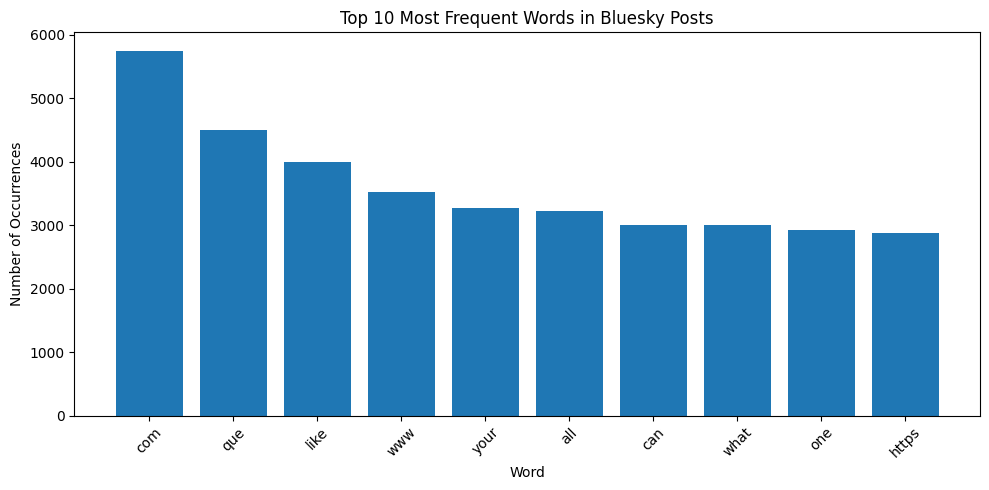

In [104]:
top_words = filtered_words.most_common(10)

words = [x[0] for x in top_words]
counts = [x[1] for x in top_words]

plt.figure(figsize=(10, 5))

plt.bar(words, counts)

plt.title("Top 10 Most Frequent Words in Bluesky Posts")
plt.xlabel("Word")
plt.ylabel("Number of Occurrences")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Hashtag ที่พบมากที่สุด:** #art จำนวน 12 โพสต์  
**Hashtag รองลงมา:** #nsfw จำนวน 11 โพสต์ และ #photography จำนวน 9 โพสต์  
**หัวข้อที่พบ:** ศิลปะ การถ่ายภาพ และหัวข้อเกี่ยวกับ AI เช่น #ai จำนวน 8 โพสต์

###**ข้อ 4: ข้อมูลนี้บอกอะไรได้ และบอกอะไรไม่ได้**

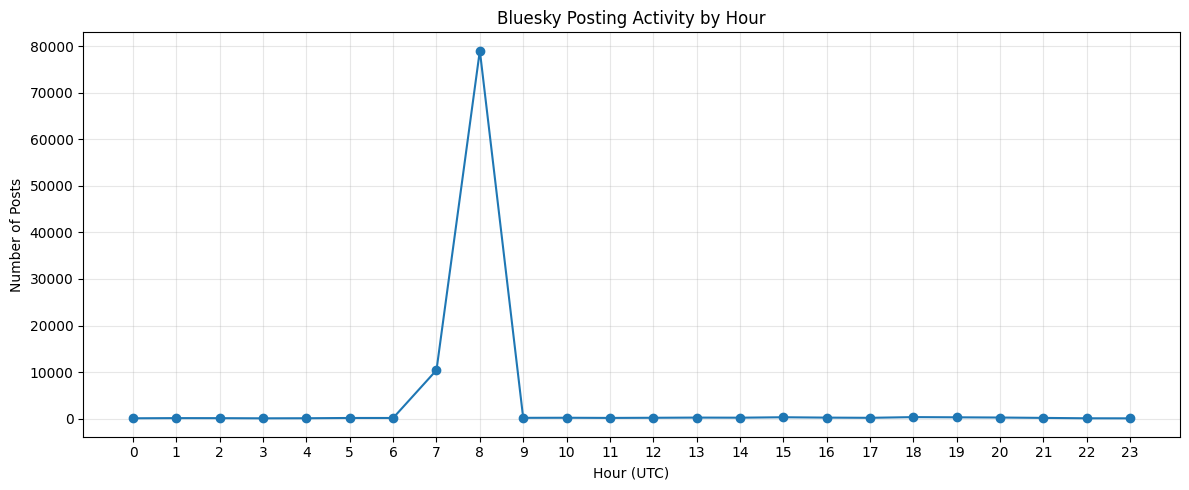

In [106]:
import matplotlib.pyplot as plt

hourly_posts = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_posts.index,
    hourly_posts.values,
    marker="o"
)

plt.title("Bluesky Posting Activity by Hour")
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Posts")
plt.xticks(range(24))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [108]:
peak_hour = int(hourly_posts.idxmax())
peak_count = hourly_posts.max()

print(f"ช่วงเวลาที่มีการโพสต์มากที่สุด: {peak_hour:02d}:00–{peak_hour:02d}:59 UTC")
print(f"จำนวนโพสต์: {peak_count:,}")

ช่วงเวลาที่มีการโพสต์มากที่สุด: 08:00–08:59 UTC
จำนวนโพสต์: 79,035


**ข้อมูลนี้บอกอะไรได้**
1. สามารถดูช่วงเวลาที่ผู้ใช้งานมีการโพสต์มากหรือน้อยได้
2. สามารถดูภาษาที่พบในข้อมูลและสัดส่วนของแต่ละภาษาได้
3. สามารถเห็นหัวข้อหรือประเด็นที่ผู้ใช้งานพูดถึงผ่าน Hashtag และ Keyword
ข้อจำกัดของข้อมูล
1. ข้อมูลที่ใช้เป็นเพียงบางไฟล์จาก dataset จึงอาจไม่สะท้อนผู้ใช้ Bluesky ทั้งหมด
2. ข้อมูลเป็นโพสต์สาธารณะ จึงไม่สามารถใช้สรุปความคิดเห็นของผู้ใช้งานทั้งหมดได้
3. การตรวจภาษาด้วย langdetect เป็นการคาดการณ์จากข้อความ จึงอาจจำแนกภาษาผิดในข้อความสั้นหรือข้อความที่มีหลายภาษา
4. Hashtag ที่พบมากไม่ได้หมายความว่าผู้ใช้ทุกคนมีความคิดเห็นแบบเดียวกัน
5. ข้อมูลนี้ใช้ดู รูปแบบการโพสต์และหัวข้อที่ปรากฏในข้อมูล แต่ไม่เพียงพอที่จะสรุปเหตุผลหรือความรู้สึกของผู้โพสต์


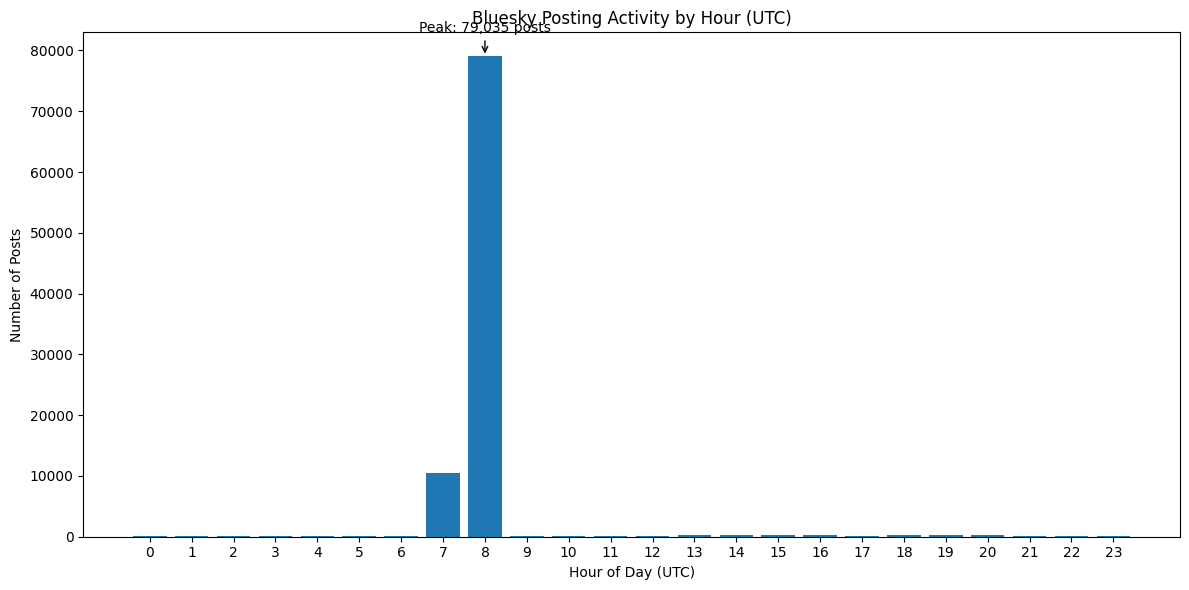

ช่วงเวลาที่มีการโพสต์มากที่สุด: 08:00–08:59 UTC
จำนวนโพสต์: 79,035 โพสต์


In [121]:
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

# นับจำนวนโพสต์ในแต่ละชั่วโมง
hourly_posts = (
    df.groupby("hour")
      .size()
      .reindex(range(24), fill_value=0)
)

# หาชั่วโมงที่มีโพสต์มากที่สุด
peak_hour = hourly_posts.idxmax()
peak_count = hourly_posts.max()

# สร้างกราฟ
plt.figure(figsize=(12, 6))

plt.bar(
    hourly_posts.index,
    hourly_posts.values
)

plt.title("Bluesky Posting Activity by Hour (UTC)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Posts")
plt.xticks(range(24))

# แสดงค่าบนแท่งที่สูงสุด
plt.annotate(
    f"Peak: {peak_count:,} posts",
    xy=(peak_hour, peak_count),
    xytext=(peak_hour, peak_count * 1.05),
    ha="center",
    arrowprops=dict(arrowstyle="->")
)

plt.tight_layout()
plt.show()

print(f"ช่วงเวลาที่มีการโพสต์มากที่สุด: {peak_hour:02d}:00–{peak_hour:02d}:59 UTC")
print(f"จำนวนโพสต์: {peak_count:,} โพสต์")

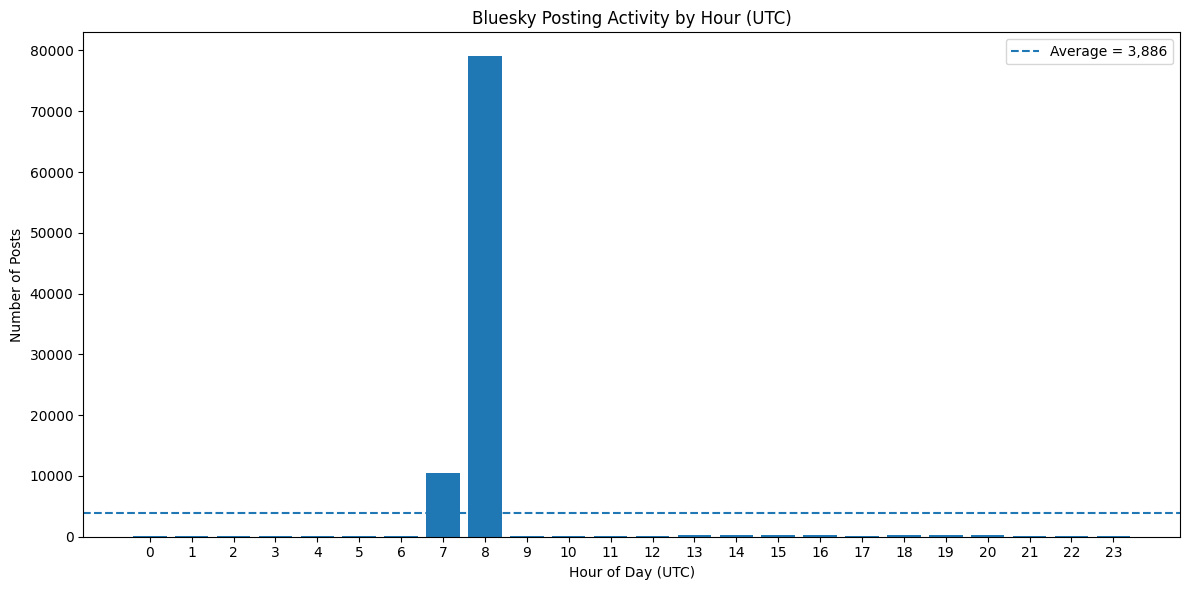

In [120]:
average_posts = hourly_posts.mean()

plt.figure(figsize=(12, 6))

plt.bar(
    hourly_posts.index,
    hourly_posts.values
)

plt.axhline(
    average_posts,
    linestyle="--",
    label=f"Average = {average_posts:,.0f}"
)

plt.title("Bluesky Posting Activity by Hour (UTC)")
plt.xlabel("Hour of Day (UTC)")
plt.ylabel("Number of Posts")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

In [111]:
print("INSIGHT")
print(
    f"ช่วงเวลาที่มีการโพสต์สูงสุดคือ "
    f"{peak_hour:02d}:00–{peak_hour:02d}:59 UTC "
    f"จำนวน {peak_count:,} โพสต์ "
    f"จากข้อมูลทั้งหมด {len(df):,} โพสต์"
)

INSIGHT
ช่วงเวลาที่มีการโพสต์สูงสุดคือ 08:00–08:59 UTC จำนวน 79,035 โพสต์ จากข้อมูลทั้งหมด 100,000 โพสต์


In [112]:
thai_hour = (peak_hour + 7) % 24

print(
    f"เมื่อแปลงเป็นเวลาไทย: "
    f"{thai_hour:02d}:00–{thai_hour:02d}:59 น."
)

เมื่อแปลงเป็นเวลาไทย: 15:00–15:59 น.
